In [1]:
import pandas as pd
import numpy as np
import seaborn as sb

In [2]:
df=pd.read_csv("/Users/aayushsharma/Downloads/archive (2)/sign_mnist_train/sign_mnist_train.csv")

In [3]:
df_train=pd.read_csv("/Users/aayushsharma/Downloads/archive (2)/sign_mnist_test.csv")

In [35]:
df

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,3,107,118,127,134,139,143,146,150,153,...,207,207,207,207,206,206,206,204,203,202
1,6,155,157,156,156,156,157,156,158,158,...,69,149,128,87,94,163,175,103,135,149
2,2,187,188,188,187,187,186,187,188,187,...,202,201,200,199,198,199,198,195,194,195
3,2,211,211,212,212,211,210,211,210,210,...,235,234,233,231,230,226,225,222,229,163
4,13,164,167,170,172,176,179,180,184,185,...,92,105,105,108,133,163,157,163,164,179
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
27450,13,189,189,190,190,192,193,193,193,193,...,132,165,99,77,52,200,234,200,222,225
27451,23,151,154,157,158,160,161,163,164,166,...,198,198,198,198,198,196,195,195,195,194
27452,18,174,174,174,174,174,175,175,174,173,...,121,196,209,208,206,204,203,202,200,200
27453,17,177,181,184,185,187,189,190,191,191,...,119,56,27,58,102,79,47,64,87,93


In [4]:
arr=df.iloc[1,1:].to_numpy().reshape(28,28)
arr

array([[155, 157, 156, 156, 156, 157, 156, 158, 158, 157, 158, 156, 154,
        154, 153, 152, 151, 149, 149, 148, 147, 146, 144, 142, 143, 138,
         92, 108],
       [158, 159, 159, 159, 160, 160, 160, 160, 160, 160, 160, 159, 158,
        157, 155, 154, 153, 152, 151, 150, 149, 149, 147, 147, 146, 142,
        116, 143],
       [161, 161, 161, 161, 162, 161, 162, 162, 162, 162, 161, 161, 161,
        160, 159, 158, 156, 155, 154, 153, 152, 152, 151, 150, 147, 147,
        125, 140],
       [165, 164, 164, 165, 165, 165, 165, 165, 164, 164, 164, 165, 163,
        163, 162, 161, 159, 159, 158, 156, 156, 155, 152, 153, 154, 151,
        124, 126],
       [166, 167, 166, 167, 167, 166, 167, 167, 167, 167, 166, 167, 165,
        165, 164, 163, 162, 162, 161, 160, 156, 151, 154, 176, 145, 122,
        144, 100],
       [168, 169, 168, 169, 169, 168, 169, 170, 170, 170, 169, 168, 167,
        166, 167, 165, 162, 159, 159, 156, 151, 165, 171, 146,  94, 130,
        159, 111],
       [17

<Axes: >

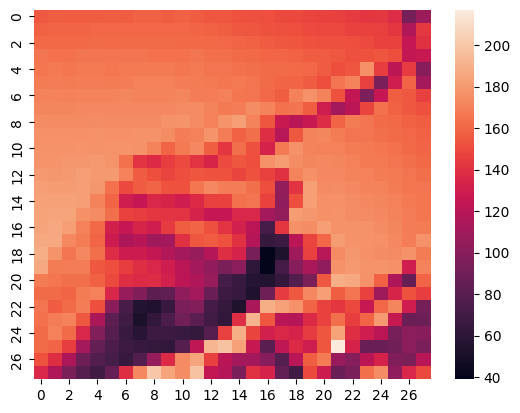

In [5]:
sb.heatmap(arr)

In [6]:
def img(ar):
    arr=ar.to_numpy().reshape(28,28)
    return arr

In [7]:

    arr=df.iloc[:,1:].to_numpy().reshape(-1,28,28)

In [8]:
arr=arr.reshape(-1,28,28,1)

In [9]:
arr=arr/255.

In [23]:
# import keras from 

In [42]:
import cv2

In [19]:
from tensorflow import keras
from keras.layers import *
from keras.applications.vgg16 import VGG16
from keras.models import Model

In [20]:
inputs = Input(shape=(28,28,1))

x = Concatenate()([inputs, inputs, inputs])

x = Resizing(224,224)(x)
model=VGG16(weights="imagenet",include_top=False,input_tensor=x)

In [27]:
model.summary()

Model: "vgg16"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 28, 28, 1)]          0         []                            
                                                                                                  
 concatenate (Concatenate)   (None, 28, 28, 3)            0         ['input_1[0][0]',             
                                                                     'input_1[0][0]',             
                                                                     'input_1[0][0]']             
                                                                                                  
 resizing (Resizing)         (None, 224, 224, 3)          0         ['concatenate[0][0]']         
                                                                                              

In [21]:
model.trainable=False

In [31]:
# nw_model.summary()

In [23]:
nw_model=Model(inputs=model.input,outputs=d3)

In [22]:
out=model.output
fl=Flatten()(out)
d1=Dense(32,activation="relu")(fl)
b1=BatchNormalization()(d1)
d2=Dense(64,activation="relu")(b1)
b2=BatchNormalization()(d2)
d3=Dense(24,activation="softmax")(b2)

In [24]:
nw_model.compile(loss="sparse_categorical_crossentropy",optimizer="adam",metrics=["accuracy"])

In [25]:
nw_model.fit(arr,df["label"],epochs=5)

Epoch 1/5
858/858 [==============================] - 426s 496ms/step - loss: 0.3008 - accuracy: 0.9043
Epoch 2/5
858/858 [==============================] - 473s 551ms/step - loss: 0.0713 - accuracy: 0.9477
Epoch 3/5
858/858 [==============================] - 490s 571ms/step - loss: 0.1415 - accuracy: 0.9191
Epoch 4/5
858/858 [==============================] - 672s 783ms/step - loss: 0.1563 - accuracy: 0.9106
Epoch 5/5
858/858 [==============================] - 405s 472ms/step - loss: 0.2113 - accuracy: 0.8949


model.save("mymodel.keras")

In [ ]:
# from keras.utils.plot_models import plot_models

In [26]:
nw_model.save("mymodel2.keras")

In [ ]:
img = np.expand_dims(arr[2], axis=0)

In [ ]:
labels_new=nw_model.predict(img)

In [ ]:
np.argmax(labels_new)

In [ ]:
df_train["label"][2]

In [ ]:
img.shape

In [ ]:
cap=cv2.VideoCapture(0)
while True:
    ret,frame=cap.read()
    if not ret:
        break
    cv2.imshow("Camera",frame)
    key = cv2.waitKey(1)
    if key==ord("c"):
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        x,y=gray.shape
        x1,y1=x//4,y//4
        x2,y2=3*x//4,3*y//4
        roi=gray[y1:y2,x1:x2]
        cv2.imshow("Captured ROI", roi)
        img = cv2.resize(roi, (28,28))

        img = img.astype("float32") / 255.0

        img = np.expand_dims(img, axis=-1)
 
        img = np.expand_dims(img, axis=0)

        print("Input shape:", img.shape)
        predict_answer=nw_model.predict(img)
        print(np.argmax(predict_answer))
    if key == ord('q'):
        break
cap.release()
cv2.destroyAllWindows()

In [ ]:
sb.heatmap(df_train.iloc[2,1:].to_numpy().reshape(28,28))